In [5]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [6]:
# import necessary layers  
from tensorflow.keras.layers import Input, Conv2D 
from tensorflow.keras.layers import MaxPool2D, Flatten, Dense 
from tensorflow.keras import Model
# input

input = Input(shape =(28,28,1))

# 1st Conv Block

x = Conv2D (filters =16, kernel_size =3, padding ='same', activation='relu')(input)
x = MaxPool2D(pool_size =2, strides =2, padding ='same')(x)

# 2nd Conv Block

x = Conv2D (filters =32, kernel_size =3, padding ='same', activation='relu')(x)
x = MaxPool2D(pool_size =2, strides =2, padding ='same')(x)


x = Flatten()(x)
x = Dense(units = 16, activation ='relu')(x)
output = Dense(units = 1, activation ='sigmoid')(x)
# creating the model

model = Model (inputs=input, outputs =output)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 16)        160       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 16)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 7, 7, 32)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 1568)              0     

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [5]:
x_train.shape

(60000, 28, 28)

In [6]:
y_train.shape

(60000,)

In [7]:
y_train[0]

5

In [8]:
y_train[1]

0

In [12]:
y_train_binary = [ 1 if y_train[i] == 1 else 0 for i in range(len(y_train)) ]

In [13]:
y_train_binary.shape

AttributeError: 'list' object has no attribute 'shape'

In [14]:
a = y_train == 1

In [15]:
a.shape

(60000,)

In [16]:
a[0]

False

In [17]:
a.astype(int)

array([0, 0, 0, ..., 0, 0, 0])

In [18]:
a.shape

(60000,)

In [19]:
len(a)

60000

In [21]:
count = 0
for i in a:
    if i == 1:
        count += 1
print(count)

6742


# Converting to binary data

In [8]:
binary_train_data = (y_train == 1).astype(int)

In [9]:
count = 0
for i in binary_train_data:
    if i == 1:
        count += 1
print(count)

6742


In [10]:
binary_test_data = (y_test == 1).astype(int)

In [11]:
count = 0
for i in binary_test_data:
    if i == 1:
        count += 1
print(count)

1135


In [12]:
model.compile(
    optimizer=keras.optimizers.RMSprop(),  # Optimizer
    # Loss function to minimize
    loss=keras.losses.binary_crossentropy,
    # List of metrics to monitor
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)

In [13]:
print("Fit model on training data")
history = model.fit(
    x_train,
    binary_train_data,
    batch_size=64,
    epochs=3,
)

Fit model on training data
Epoch 1/3
938/938 [==============================] - 10s 10ms/step - loss: 0.0450 - sparse_categorical_accuracy: 0.8876
Epoch 2/3
938/938 [==============================] - 10s 10ms/step - loss: 0.0143 - sparse_categorical_accuracy: 0.8876
Epoch 3/3
938/938 [==============================] - 10s 11ms/step - loss: 0.0119 - sparse_categorical_accuracy: 0.8876


In [14]:
import numpy
predictions = model.predict(x_test)

313/313 [==============================] - 1s 2ms/step


In [15]:
predictions.shape

(10000, 1)

In [16]:
predictions[1]

array([1.7581199e-08], dtype=float32)

In [17]:
predicted_data = (predictions >= 7.0e-1).astype(int)

In [18]:
matched = 0
not_matched = 0
for i in range(10000):
    if predicted_data[i] == 1:
        matched += 1
    else:
        not_matched += 1
print(f"matched one : {matched}")      
print(f"non matched one : {not_matched}")

matched one : 1164
non matched one : 8836


In [19]:
matched = 0
not_matched = 0
for i in range(10000):
    if binary_test_data[i] == 1:
        matched += 1
    else:
        not_matched += 1
print(f"matched one : {matched}")      
print(f"non matched one : {not_matched}")

matched one : 1135
non matched one : 8865


In [20]:
matched = 0
not_matched = 0
for i in range(10000):
    if binary_test_data[i] == 1:
        matched += 1
    else:
        not_matched += 1
print(f"matched one : {matched}")      
print(f"non matched one : {not_matched}")

matched one : 1135
non matched one : 8865


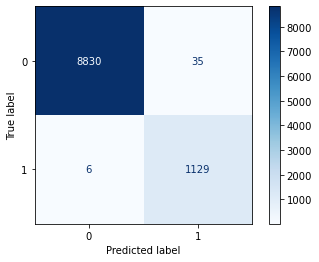

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

y_pred = predicted_data
y_test = binary_test_data
labels = [0, 1]

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues)
plt.savefig("confusion_matrix.jpg")
plt.show()

[2 1 0]


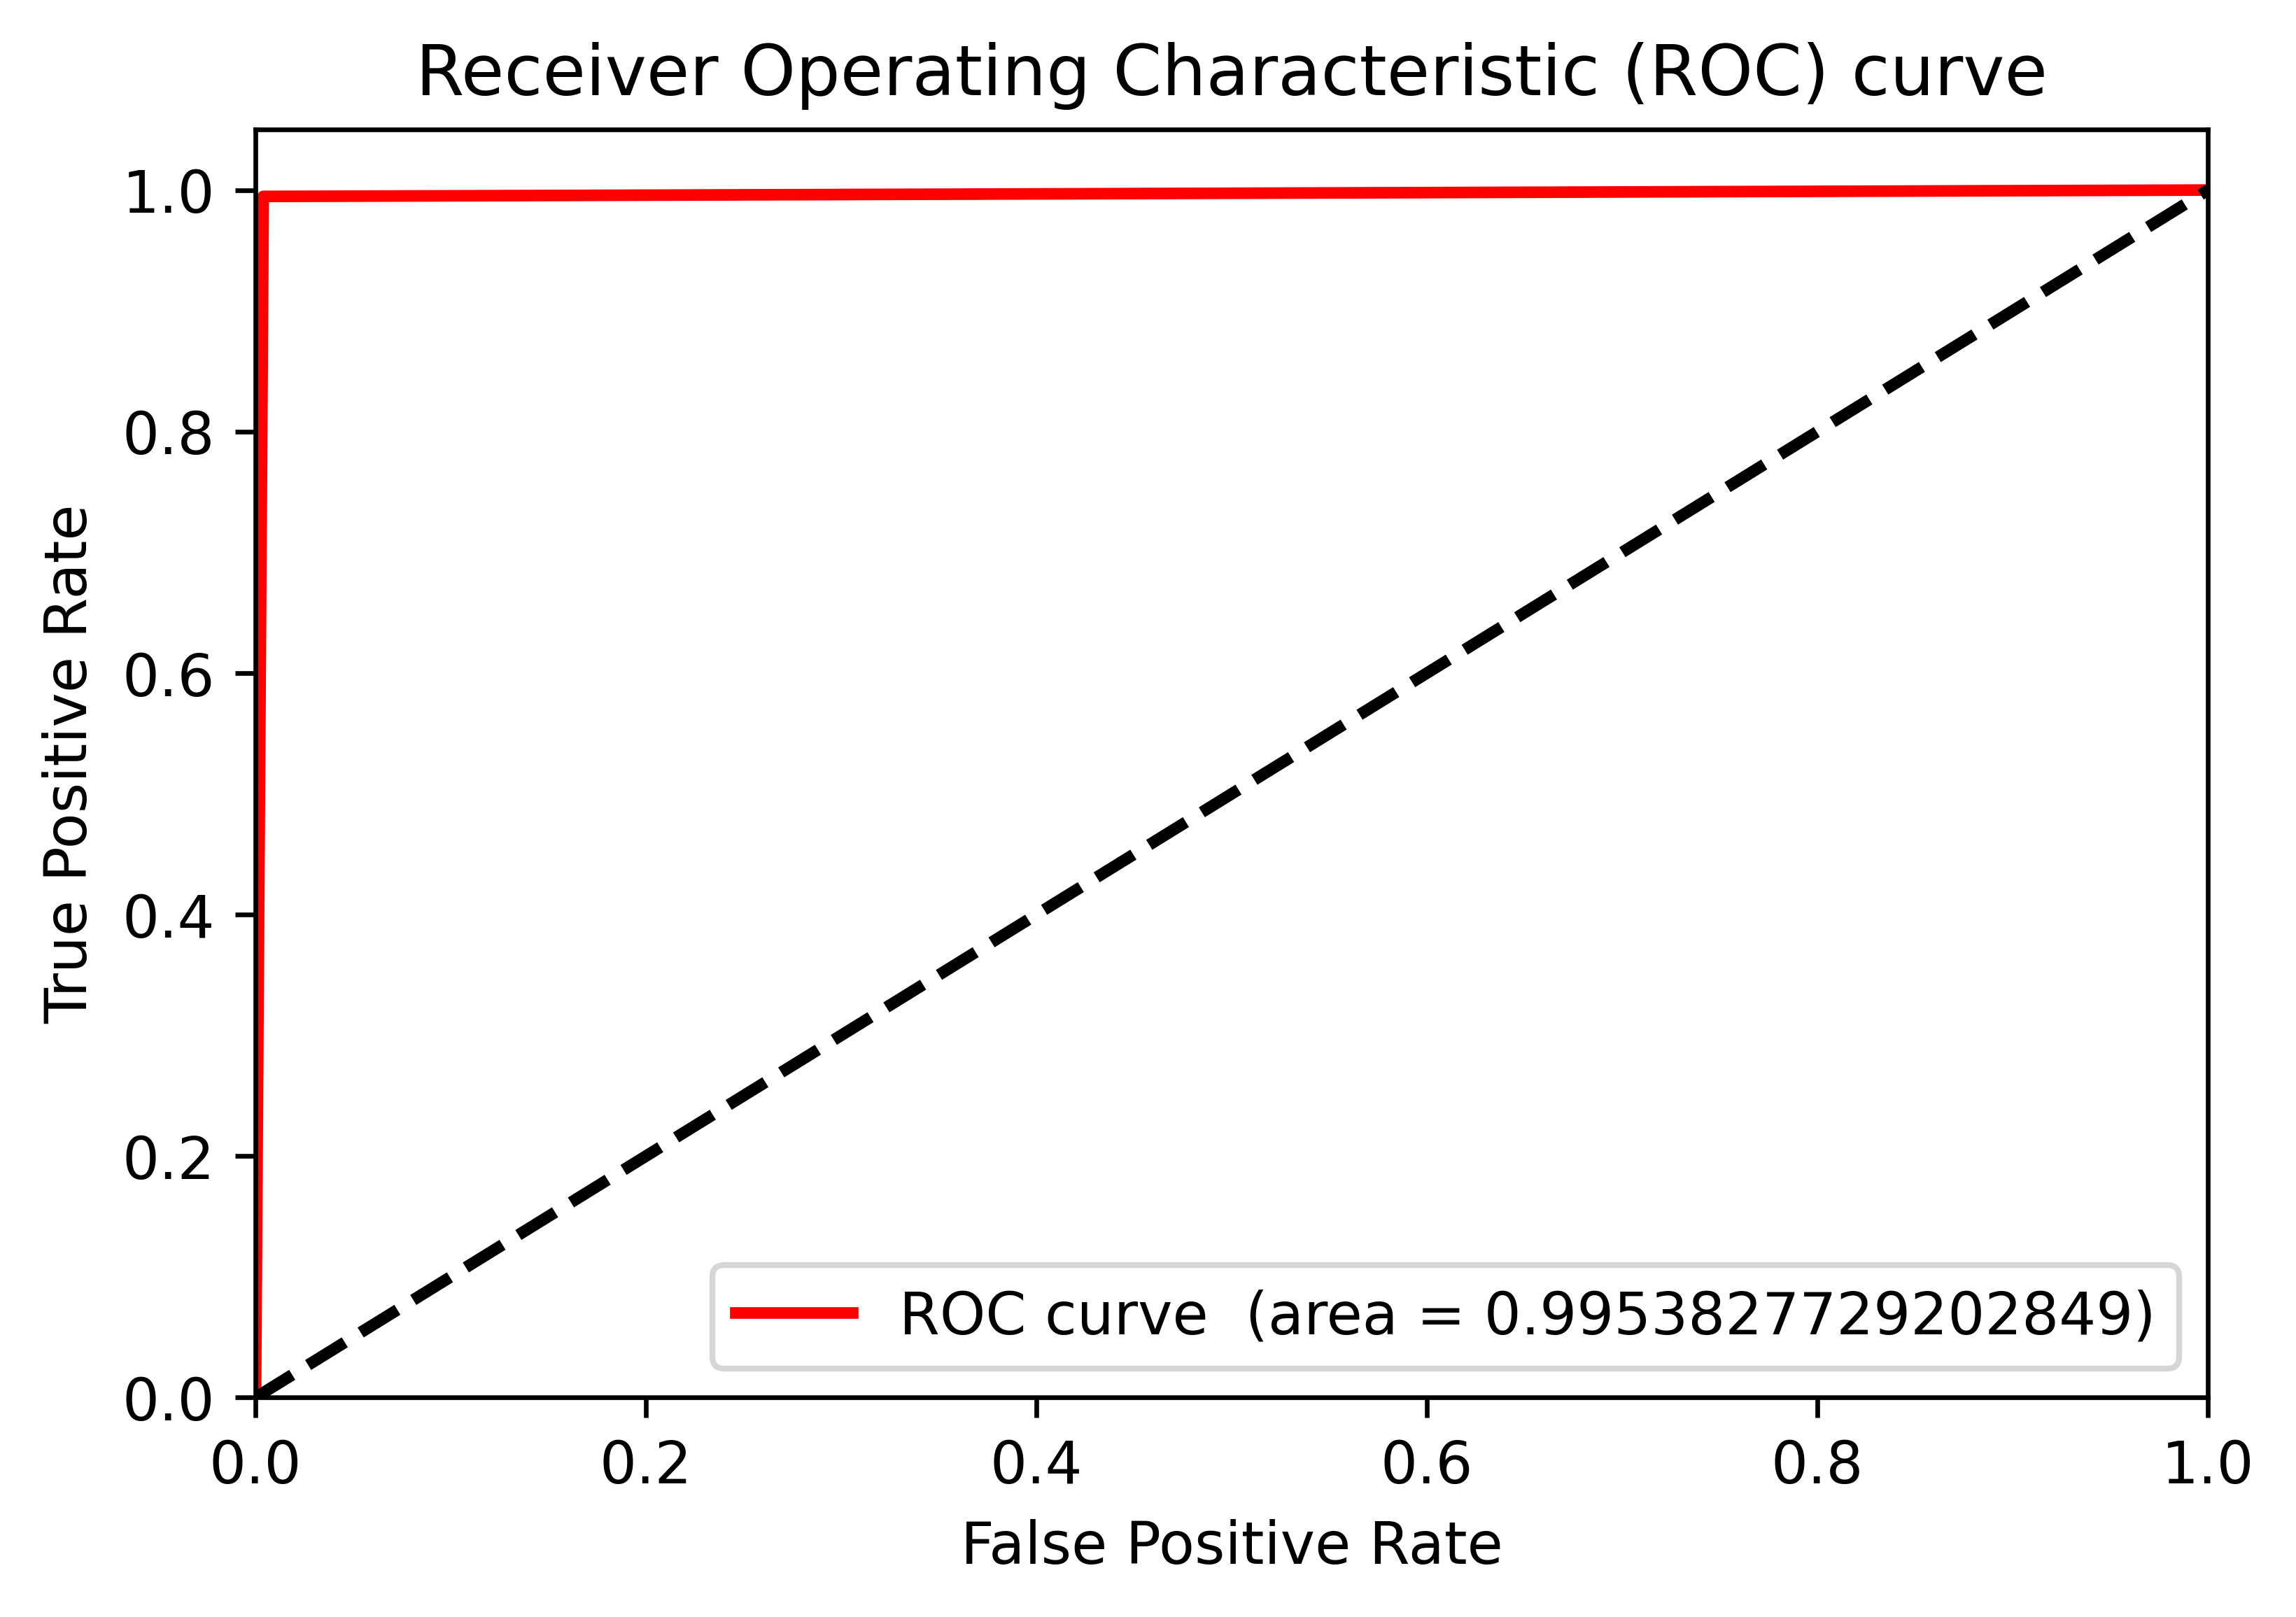

In [22]:

import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize



n_classes = 2
y_labelized_test = binary_test_data
y_labelized_pred = predicted_data

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
thresholds = dict()

fpr, tpr, thresholds = roc_curve(y_labelized_test, y_labelized_pred, drop_intermediate=False)
roc_auc = auc(fpr, tpr)



# Plot all ROC curves
#plt.figure(figsize=(10,5))
plt.figure(dpi=600)
lw = 2



string_label = f"ROC curve  (area = {roc_auc})"
plt.plot(fpr, tpr, color="red", 
         lw=lw,label=string_label,)

plt.plot([0, 1], [0, 1], "k--", lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) curve")
plt.savefig("ROC2.jpg")
plt.legend()
print(thresholds)

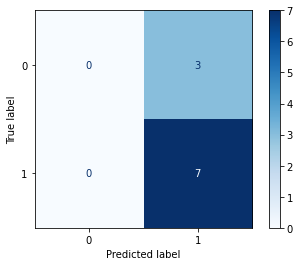

In [72]:
y_tester = [1 for i in range]
y_predicter = [1,1,1,1,1,1,1,1,1,1]


from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

y_pred = y_predicter
y_test = y_tester
labels = [0, 1]

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues)
plt.savefig("confusion_matrix.jpg")
plt.show()

[2 1 0]


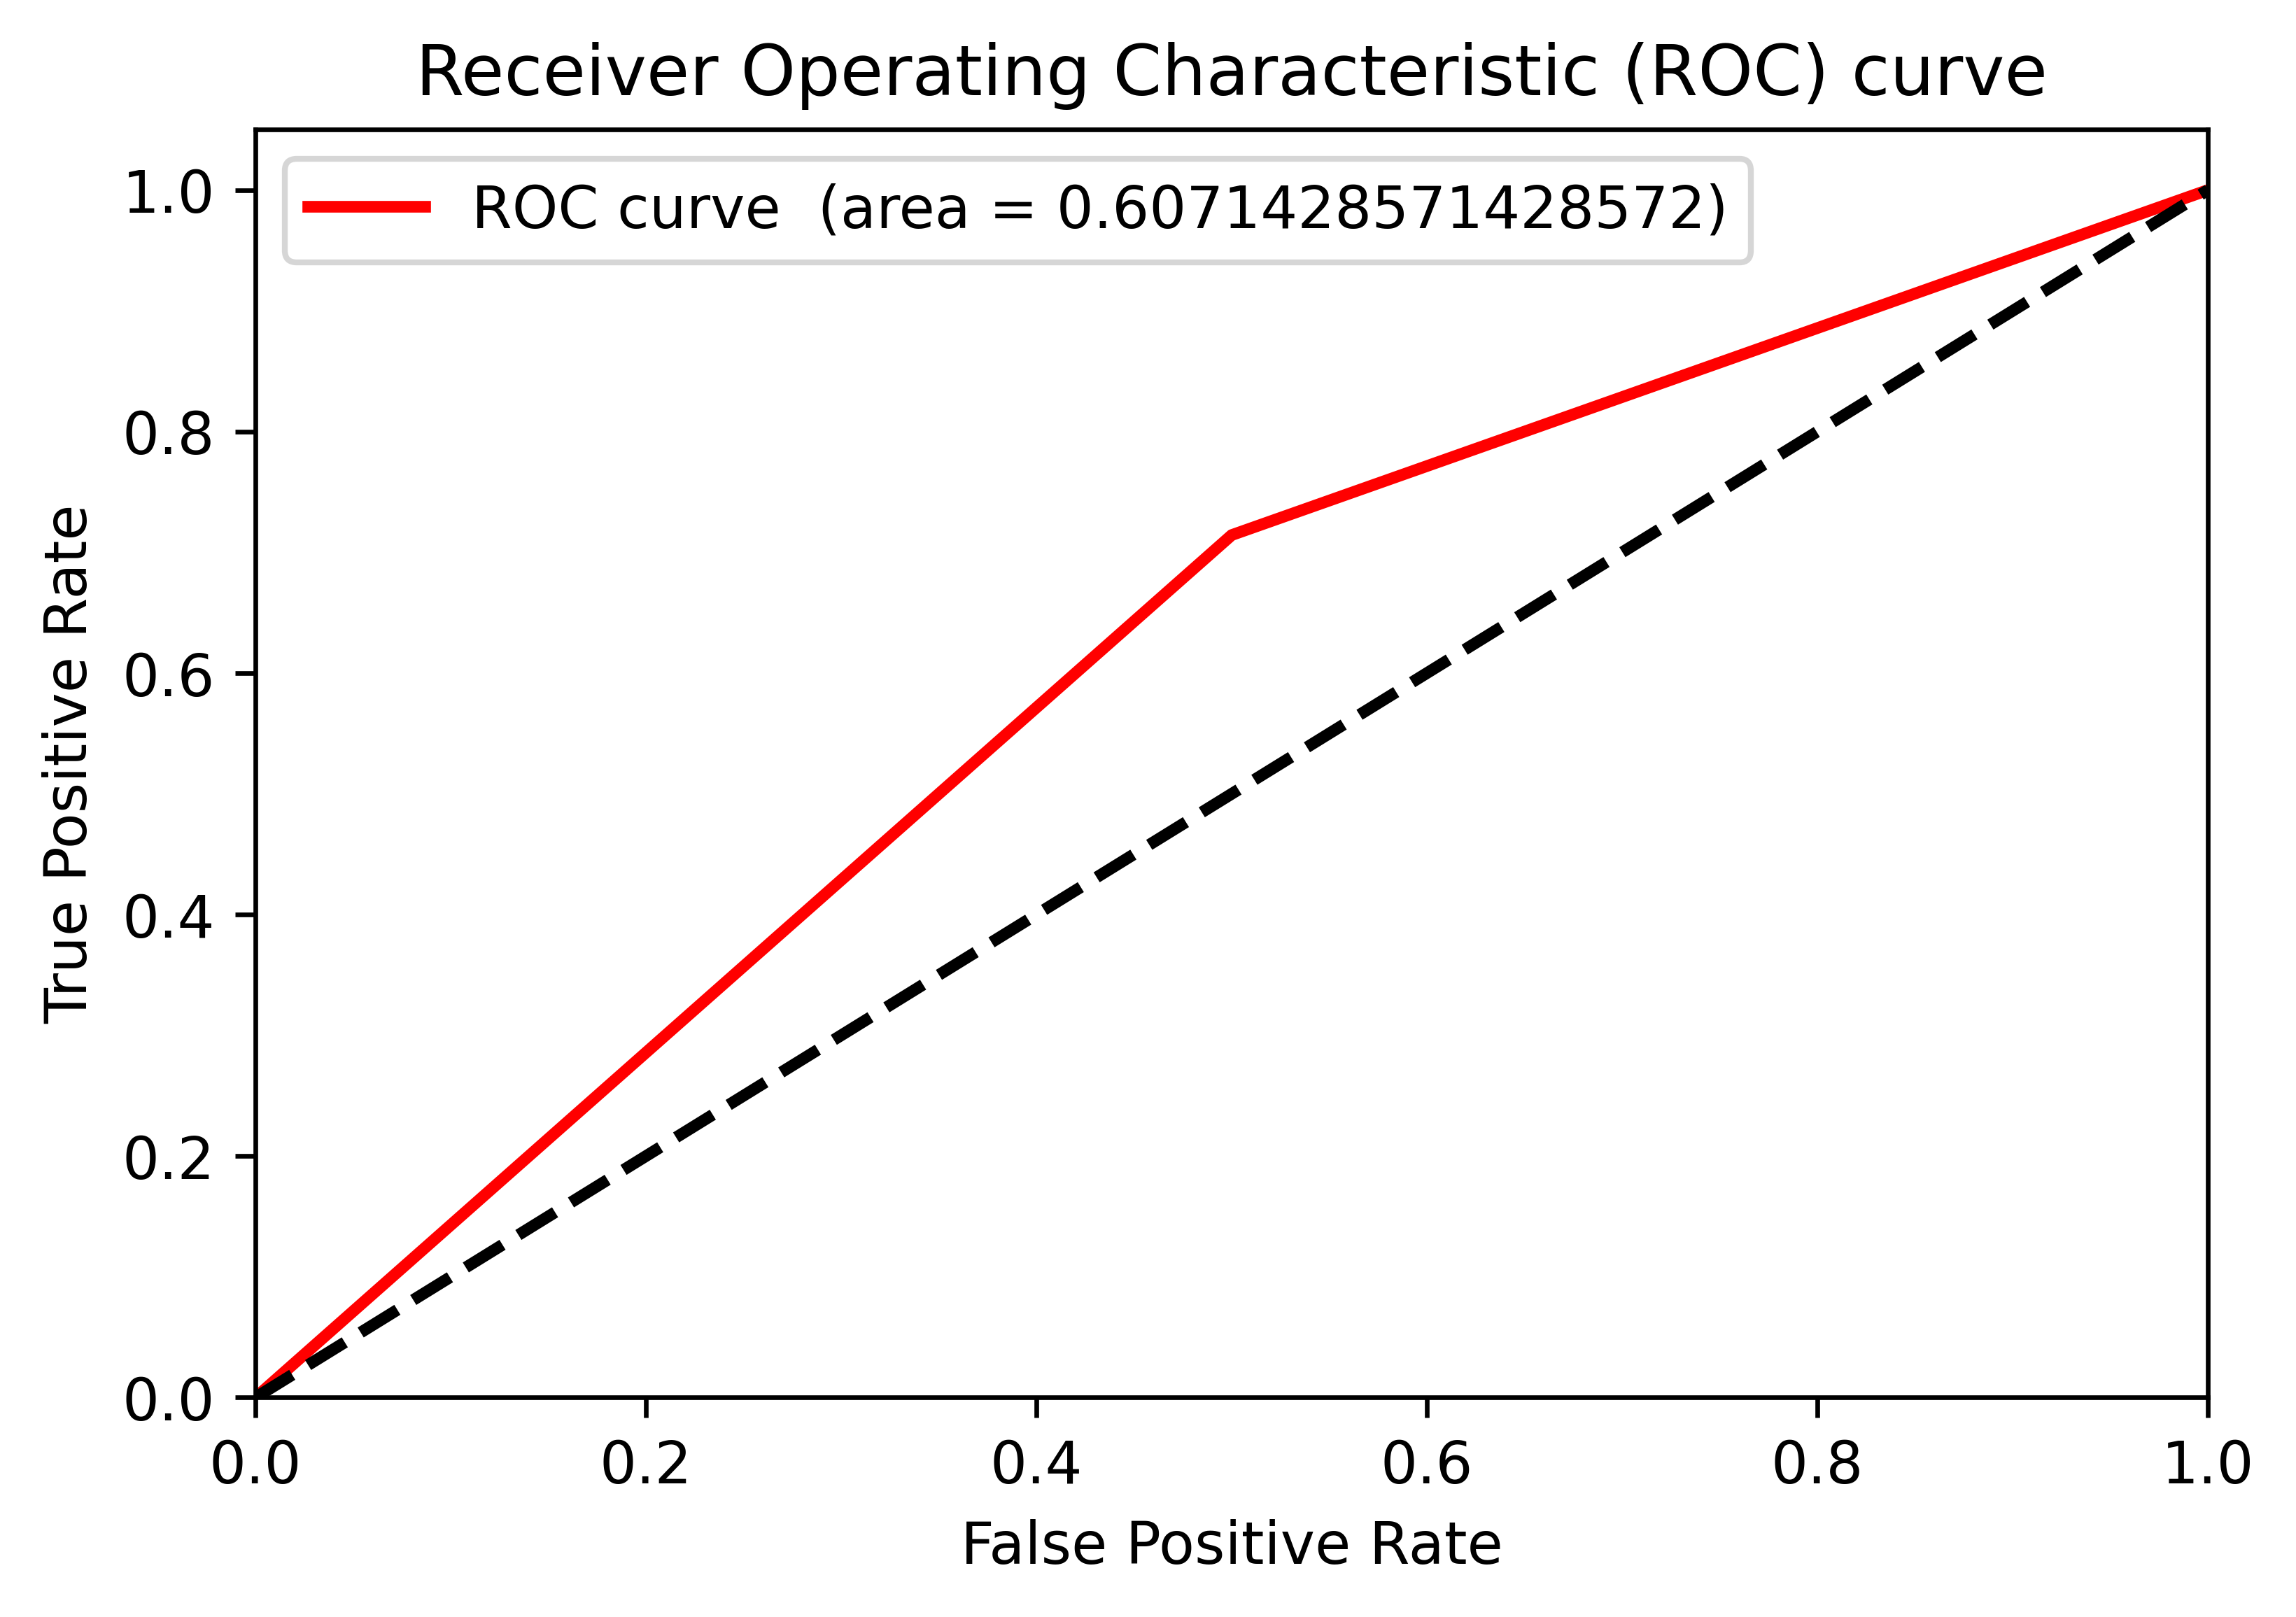

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize

y_tester = [1,1,1,1,1,0,0,0,0,1,1]
y_predicter = [1,0,1,1,0,0,1,0,1,1, 1]


y_labelized_test = y_tester
y_labelized_pred = y_predicter

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
thresholds = dict()

fpr, tpr, thresholds = roc_curve(y_labelized_test, y_labelized_pred, drop_intermediate=False)
roc_auc = auc(fpr, tpr)



# Plot all ROC curves
#plt.figure(figsize=(10,5))
plt.figure(dpi=600)
lw = 2



string_label = f"ROC curve  (area = {roc_auc})"
plt.plot(fpr, tpr, color="red", 
         lw=lw,label=string_label,)

plt.plot([0, 1], [0, 1], "k--", lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) curve")
#plt.savefig("ROC2.jpg")
plt.legend()
print(thresholds)

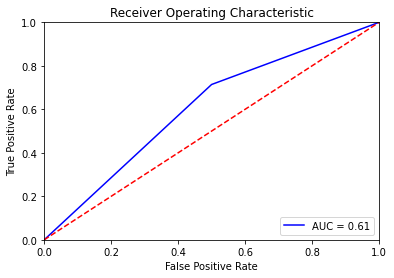

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize

y_tester = [1,1,1,1,1,0,0,0,0,1,1]
y_predicter = [1,0,1,1,0,0,1,0,1,1, 1]


y_labelized_test = y_tester
y_labelized_pred = y_predicter

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
thresholds = dict()

fpr, tpr, thresholds = roc_curve(y_labelized_test, y_labelized_pred, drop_intermediate=False)
roc_auc = auc(fpr, tpr)

plot_sklearn_roc_curve(y_test, y_proba[:, 1])

# method I: plt
import matplotlib.pyplot as plt
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

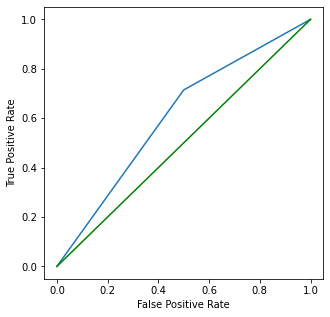

In [4]:
from sklearn.metrics import roc_curve
from sklearn.metrics import RocCurveDisplay


y_tester = [1,1,1,1,1,0,0,0,0,1,1]
y_predicter = [1,0,1,1,0,0,1,0,1,1, 1]

def plot_sklearn_roc_curve(y_real, y_pred):
    fpr, tpr, _ = roc_curve(y_real, y_pred)
    roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr).plot()
    roc_display.figure_.set_size_inches(5,5)
    plt.plot([0, 1], [0, 1], color = 'g')
# Plots the ROC curve using the sklearn methods - Good plot
plot_sklearn_roc_curve(y_tester, y_predicter)
# Plots the ROC curve using the sklearn methods - Bad plot
